# 07_降维模型-独立成分分析 ICA

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- ICA 在完整数据上拟合一次后分批 transform；各批独立重新拟合会使分量的顺序、符号和尺度不一致，不能直接拼接。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文咱们聊一个非常重要的算法模型：ICA。

咱们先简单聊一下其中的概念\~

ICA，全称为独立成分分析（Independent Component Analysis），是一种统计和计算技术，旨在将多变量信号分解为统计上独立的成分。ICA广泛应用于信号处理、神经科学、金融数据分析等领域，其目标是通过从混合信号中提取独立信号源来揭示数据的底层结构。

**独立成分分析是一种线性混合模型，假设观察到的多变量数据是若干独立成分的线性组合。**

一起来详细的看下\~

## 理论基础

ICA 的目标是从观测数据中提取出相互独立的源信号。

以下是更为细化的数学原理和步骤：

**模型假设**

ICA 的基本模型假设为：


$$
\mathbf{X} = \mathbf{A} \mathbf{S}
$$


其中：

- $\mathbf{X}$ 是观测数据矩阵，形状为 $n \times m$，$n$ 是观测变量的个数，$m$ 是样本数量。
- $\mathbf{A}$ 是未知的 $n \times n$ 混合矩阵。
- $\mathbf{S}$ 是源信号矩阵，形状为 $n \times m$，其各行表示独立的源信号。

**独立性假设**

ICA 假设源信号 $\mathbf{S}$ 的各个分量是统计独立的。这意味着对于任意两个不同的源信号 $s_i$ 和 $s_j$，它们的联合概率密度函数可以分解为各自的边缘概率密度函数的乘积：


$$
p(s_i, s_j) = p(s_i) p(s_j)
$$


### 数学原理

**1. 中心化和白化**：

**中心化**：将观测数据 $\mathbf{X}$ 的每一列减去其均值，使数据的均值为零：


$$
\mathbf{X}_{\text{centered}} = \mathbf{X} - \mathbb{E}[\mathbf{X}]
$$


**白化**：将中心化后的数据进行白化处理，使得新数据矩阵的各个维度互相不相关并具有单位方差。白化通过对协方差矩阵 $\mathbf{C}$ 进行特征值分解或奇异值分解实现：


$$
\mathbf{C} = \frac{1}{m} \mathbf{X}_{\text{centered}} \mathbf{X}_{\text{centered}}^T
$$


然后，进行特征值分解：


$$
\mathbf{C} = \mathbf{E} \mathbf{D} \mathbf{E}^T
$$


其中，$\mathbf{E}$ 是特征向量矩阵，$\mathbf{D}$ 是对角矩阵，对角线上的元素是特征值。白化矩阵为：


$$
\mathbf{V} = \mathbf{E} \mathbf{D}^{-1/2} \mathbf{E}^T
$$


白化后的数据为：


$$
\mathbf{X}_{\text{whitened}} = \mathbf{V} \mathbf{X}_{\text{centered}}
$$


**2. 寻找独立成分**：

ICA 的核心任务是找到一个线性变换矩阵 $\mathbf{W}$，使得 $\mathbf{S} = \mathbf{W} \mathbf{X}_{\text{whitened}}$ 中的各分量尽可能独立。常见的方法包括最大化非高斯性和最小化互信息。

**3. 非高斯性最大化**：

**定量非高斯性**：使用高阶统计量如偏度和峰度来衡量信号的非高斯性。独立成分通常具有较大的非高斯性。

**负熵（Negentropy）**：负熵是衡量非高斯性的一种有效指标。

负熵 $J(y)$ 定义为：  
$J(y) = H(y_{\text{gaussian}}) - H(y)$

其中 $H$ 表示熵，$y_{\text{gaussian}}$ 是与 $y$ 具有相同协方差矩阵的高斯变量。负熵越大，信号的非高斯性越强。

**4. 算法迭代**：

FastICA 算法是一种常用的求解 ICA 的方法，基于负熵的逼近，采用固定点迭代法寻找独立成分。

### FastICA 算法流程

以下是 FastICA 的详细算法流程：

**1. 数据预处理**：

- **去中心化**：将观测数据 $\mathbf{X}$ 的每一列减去其均值。


$$
\mathbf{X}_{\text{centered}} = \mathbf{X} - \mathbb{E}[\mathbf{X}]
$$


- **白化**：对中心化后的数据进行白化处理，得到新的数据矩阵 $\mathbf{X}_{\text{whitened}}$。


$$
\mathbf{X}_{\text{whitened}} = \mathbf{V} \mathbf{X}_{\text{centered}}
$$


**2. 初始值设定**：

- 随机初始化权重矩阵 $\mathbf{W}$（通常选择为单位矩阵或者随机矩阵）。

**3. 迭代过程**：

对于每个独立成分 $w_i$（第 $i$ 行权重向量）：

- **线性变换**：计算 $w_i^T \mathbf{X}_{\text{whitened}}$。


$$
\mathbf{y} = w_i^T \mathbf{X}_{\text{whitened}}
$$


- **非线性变换**：应用非线性函数 $g$ 和其导数 $g'$。常用的非线性函数包括：

  - $g(y) = \tanh(y)$
  - $g(y) = y^3$
  - $g(y) = y \cdot e^{-\frac{y^2}{2}}$

计算期望值：


$$
\mathbb{E}[\mathbf{X}_{\text{whitened}} g(w_i^T \mathbf{X}_{\text{whitened}})]
$$


和


$$
\mathbb{E}[g'(w_i^T \mathbf{X}_{\text{whitened}})]
$$


- **更新权重**：使用以下公式更新权重向量：


$$
w_i \leftarrow \mathbb{E}[\mathbf{X}_{\text{whitened}} g(w_i^T \mathbf{X}_{\text{whitened}})] - \mathbb{E}[g'(w_i^T \mathbf{X}_{\text{whitened}})] w_i
$$


- **归一化**：将 $w_i$ 归一化，以确保其长度为1：


$$
w_i \leftarrow \frac{w_i}{\|w_i\|}
$$


- **去相关**：对每个 $w_i$ 进行正交化处理，确保新得到的独立成分与之前得到的独立成分正交。可以使用 Gram-Schmidt 正交化方法：


$$
w_i \leftarrow w_i - \sum_{j=1}^{i-1} (w_i \cdot w_j) w_j
$$


然后再归一化：


$$
w_i \leftarrow \frac{w_i}{\|w_i\|}
$$


**4. 收敛判定**：

- 检查更新前后权重向量 $w_i$ 的变化是否小于某个阈值。通常使用权重向量的点积作为收敛判定标准：


$$
|\mathbf{w}_i^{\text{new}} \cdot \mathbf{w}_i^{\text{old}}| \approx 1
$$


若满足上述条件，则判定收敛，停止迭代。

**5. 输出独立成分**：

- 当所有独立成分都收敛后，计算独立成分矩阵 $\mathbf{S} = \mathbf{W} \mathbf{X}_{\text{whitened}}$。

### 详细步骤总结

**数据预处理**：

1. 去中心化观测数据 $\mathbf{X}$。
2. 白化中心化后的数据，得到 $\mathbf{X}_{\text{whitened}}$。

**算法迭代**：

1. 随机初始化权重矩阵 $\mathbf{W}$。
2. 对于每个独立成分 $w_i$，进行以下步骤：

   - 计算线性变换 $w_i^T \mathbf{X}_{\text{whitened}}$。
   - 应用非线性函数 $g$ 和其导数 $g'$。
   - 更新权重向量 $w_i$。
   - 归一化 $w_i$。
   - 正交化 $w_i$。
3. 判定权重向量的收敛，若收敛则停止迭代。

**输出结果**：

当所有独立成分收敛后，计算独立成分矩阵 $\mathbf{S} = \mathbf{W} \mathbf{X}_{\text{whitened}}$。

通过上述详细步骤，FastICA 算法能够有效地从观测数据中分离出独立成分，从而实现独立成分分析的目标。

## 完整案例

这里我来做一个合成的数据集，其中包含混合的独立信号。我们将使用 ICA 来分离这些信号。为了增加复杂性，代码中生成大数据量的数据集并进行详细的可视化分析。

假设我们有三个独立信号，分别是正弦波、方波和正态分布的随机噪声。我们将这些信号线性混合生成观测数据，并使用 ICA 从中分离出独立信号。

**生成合成数据**：

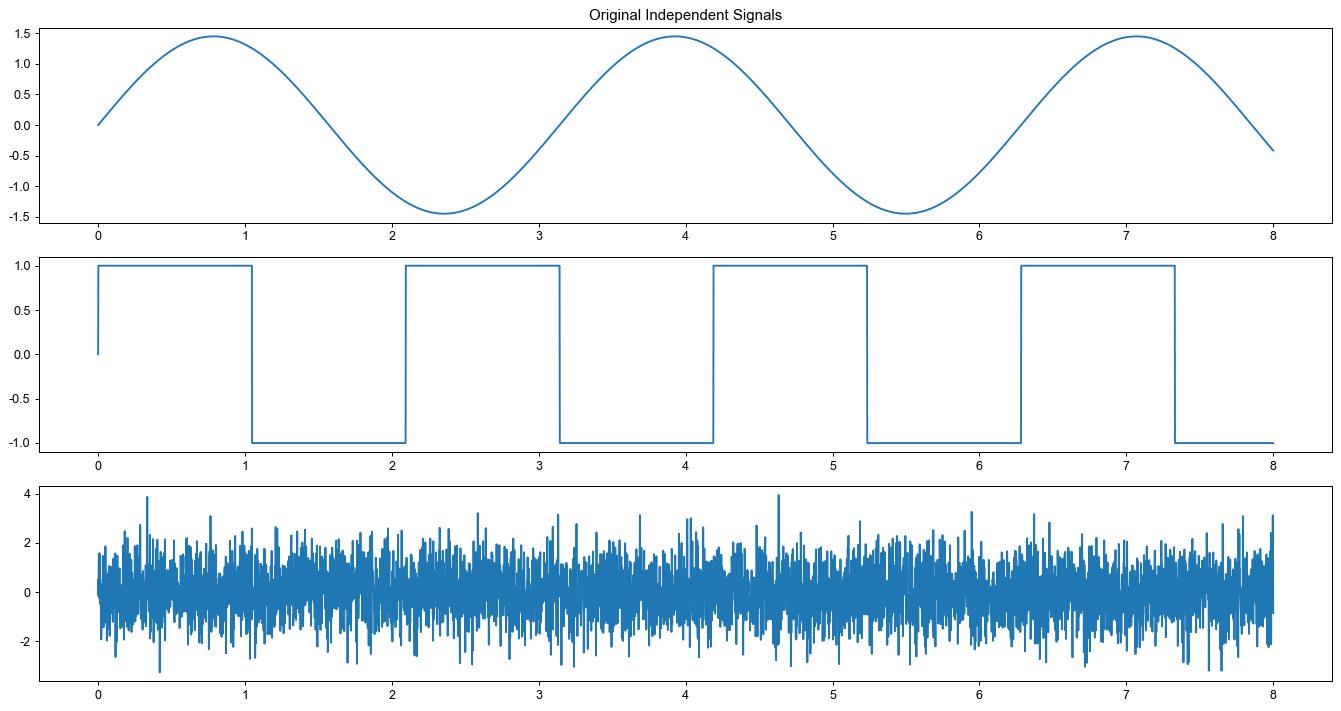

In [2]:
from sklearn.decomposition import FastICA
import seaborn as sns
# 设置随机种子
np.random.seed(42)

# 生成独立信号
n_samples = 5000
time = np.linspace(0, 8, n_samples)

# 独立信号
s1 = np.sin(2 * time)  # 正弦波
s2 = np.sign(np.sin(3 * time))  # 方波
s3 = np.random.normal(size=n_samples)  # 随机噪声

# 将独立信号组合成矩阵
S = np.c_[s1, s2, s3]
S /= S.std(axis=0)  # 标准化信号

# 生成混合信号
A = np.array([[1, 1, 1], [0.5, 2, 1], [1.5, 1, 2]])  # 混合矩阵
X = np.dot(S, A.T)  # 观测信号

# 绘制原始独立信号
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
plt.plot(time, S[:, 0])
plt.title("Original Independent Signals")
plt.subplot(3, 1, 2)
plt.plot(time, S[:, 1])
plt.subplot(3, 1, 3)
plt.plot(time, S[:, 2])
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_001.png)

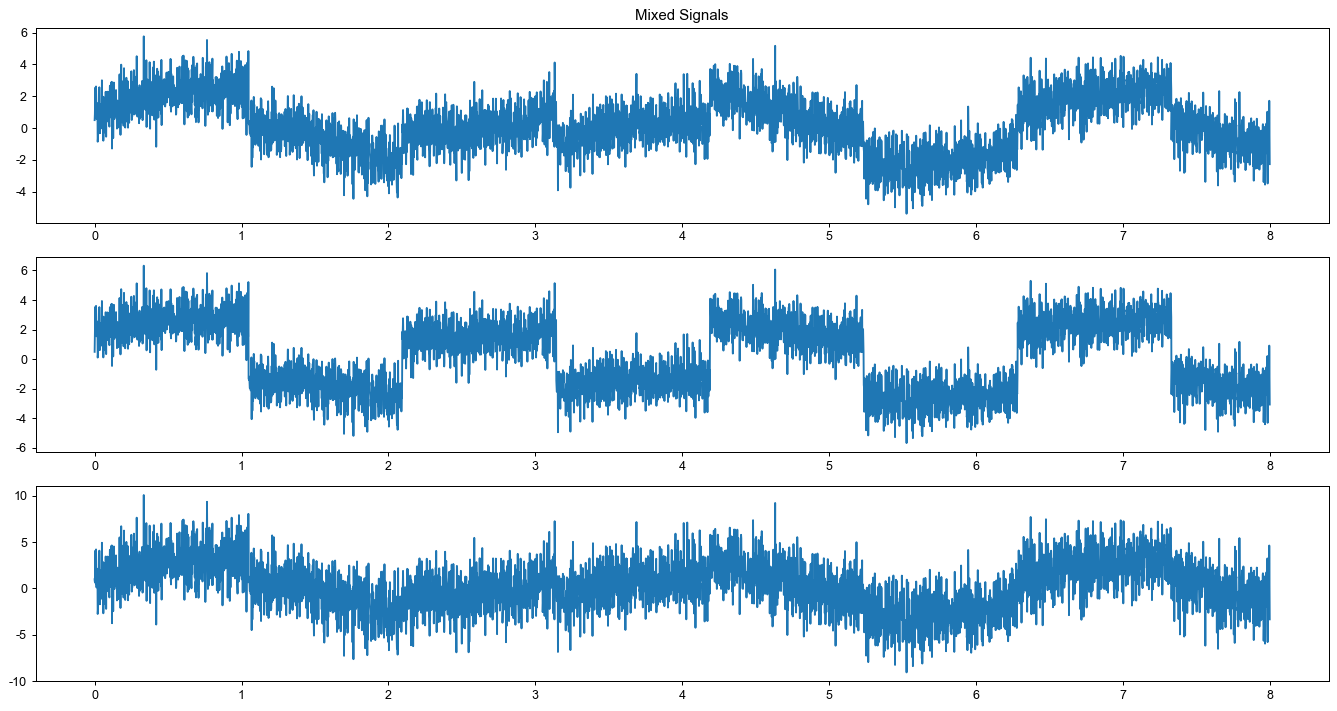

In [3]:
# 绘制混合信号
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
plt.plot(time, X[:, 0])
plt.title("Mixed Signals")
plt.subplot(3, 1, 2)
plt.plot(time, X[:, 1])
plt.subplot(3, 1, 3)
plt.plot(time, X[:, 2])
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_002.png)

**应用 ICA 算法**

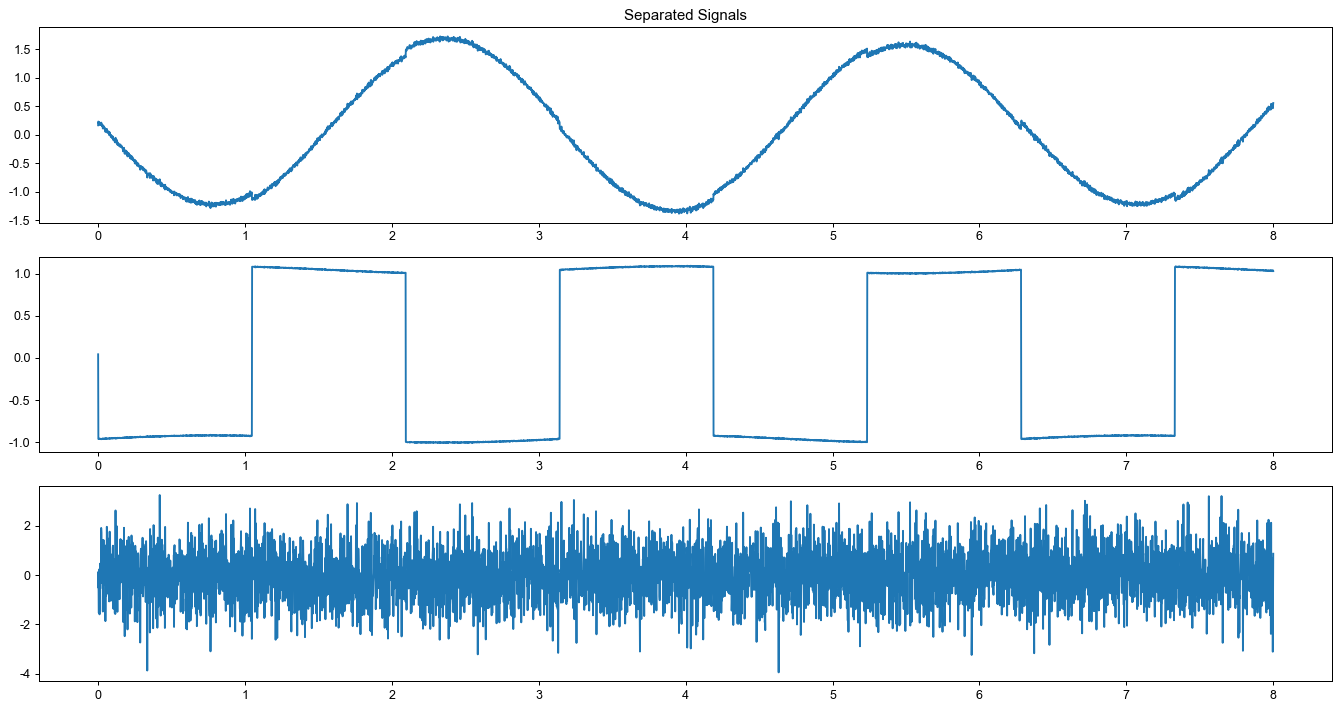

In [4]:
# 设置 FastICA 参数
n_components = 3  # 分离出三个独立成分

# 创建 FastICA 对象并拟合数据
ica = FastICA(n_components=n_components, max_iter=1000, tol=1e-4)
S_ = ica.fit_transform(X)  # 重构信号
A_ = ica.mixing_           # 混合矩阵

# 绘制分离后的信号
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
plt.plot(time, S_[:, 0])
plt.title("Separated Signals")
plt.subplot(3, 1, 2)
plt.plot(time, S_[:, 1])
plt.subplot(3, 1, 3)
plt.plot(time, S_[:, 2])
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_003.png)

**可视化原始信号和分离信号**

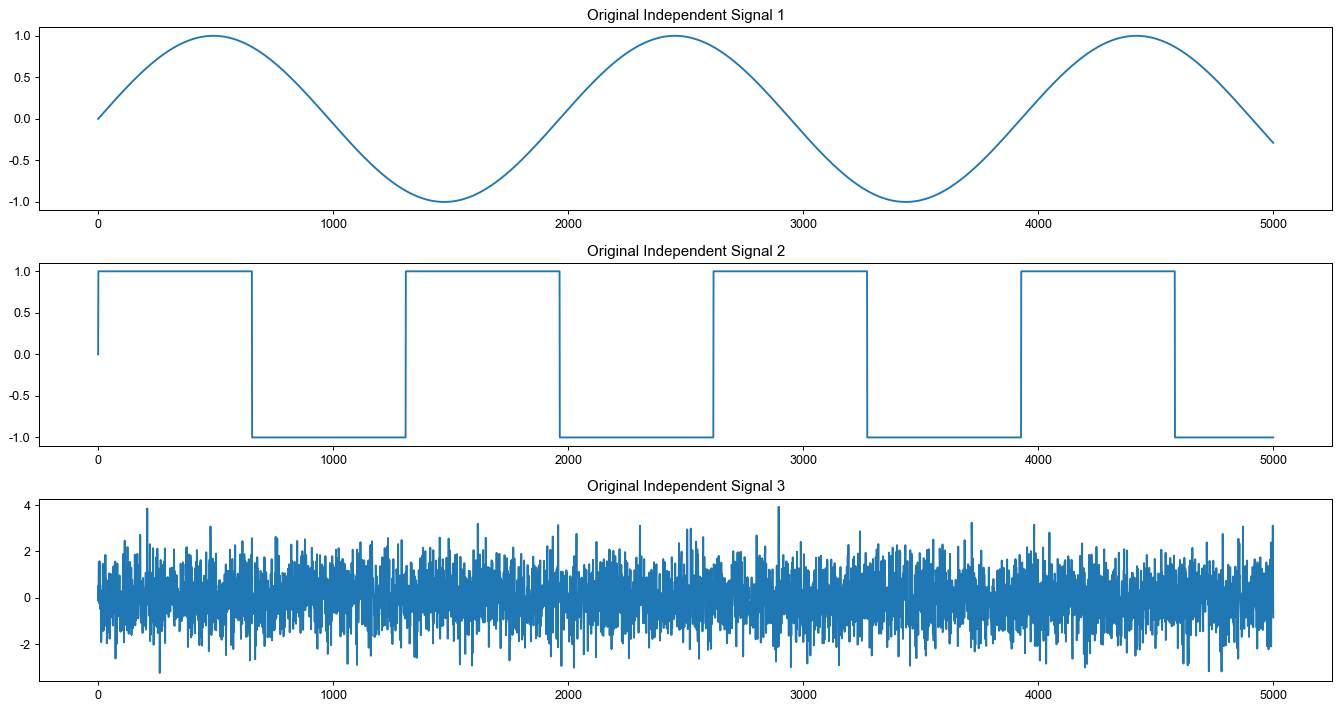

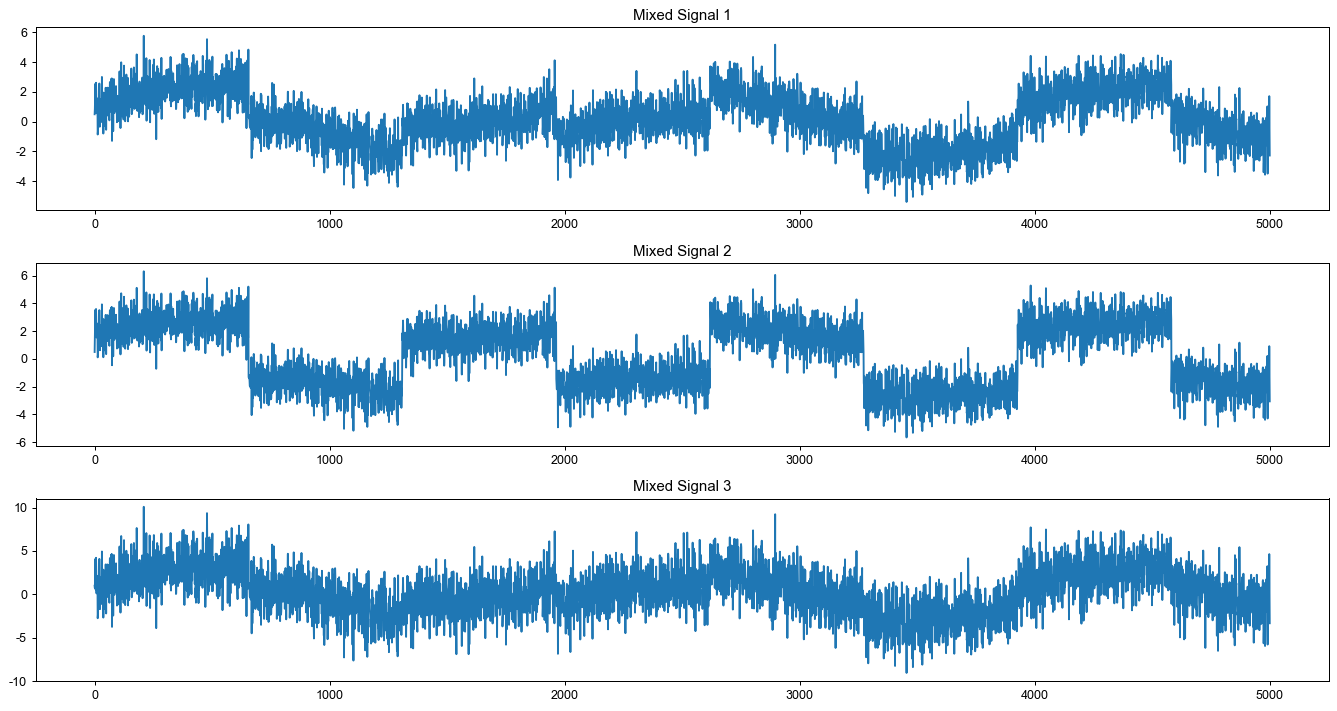

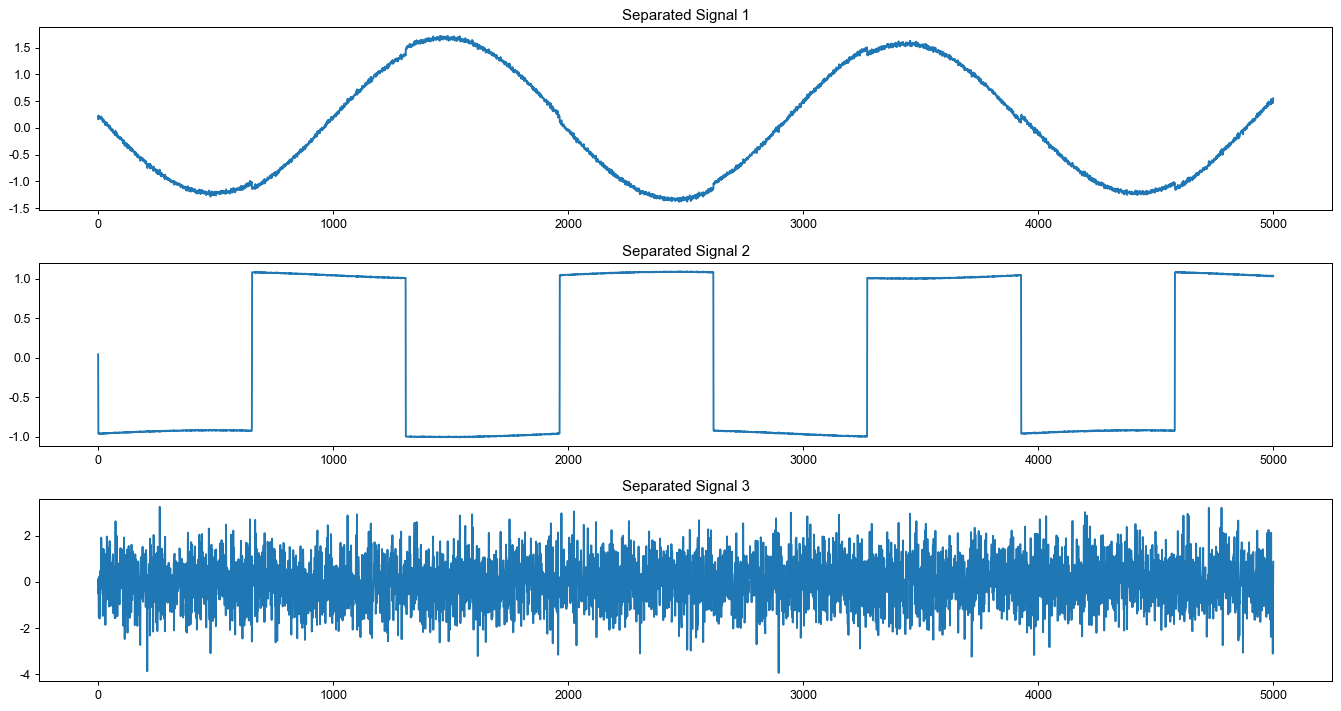

In [5]:
def plot_signals(signals, title):
    plt.figure(figsize=(15, 8))
    for i, signal in enumerate(signals, 1):
        plt.subplot(len(signals), 1, i)
        plt.plot(signal)
        plt.title(f'{title} {i}')
    plt.tight_layout()
    plt.show()

# 绘制原始独立信号
plot_signals([s1, s2, s3], title='Original Independent Signal')

# 绘制混合信号
plot_signals([X[:, 0], X[:, 1], X[:, 2]], title='Mixed Signal')

# 绘制分离信号
plot_signals([S_[:, 0], S_[:, 1], S_[:, 2]], title='Separated Signal')

![原文参考图，当前结果见代码输出](attachments/img_004.png)

![原文参考图，当前结果见代码输出](attachments/img_005.png)

**算法优化**

1. **批量处理**：对于大数据集，可以将数据分批处理以降低内存消耗。
2. **并行处理**：使用并行处理技术加速计算，尤其在处理高维数据时。

**批量处理示例**

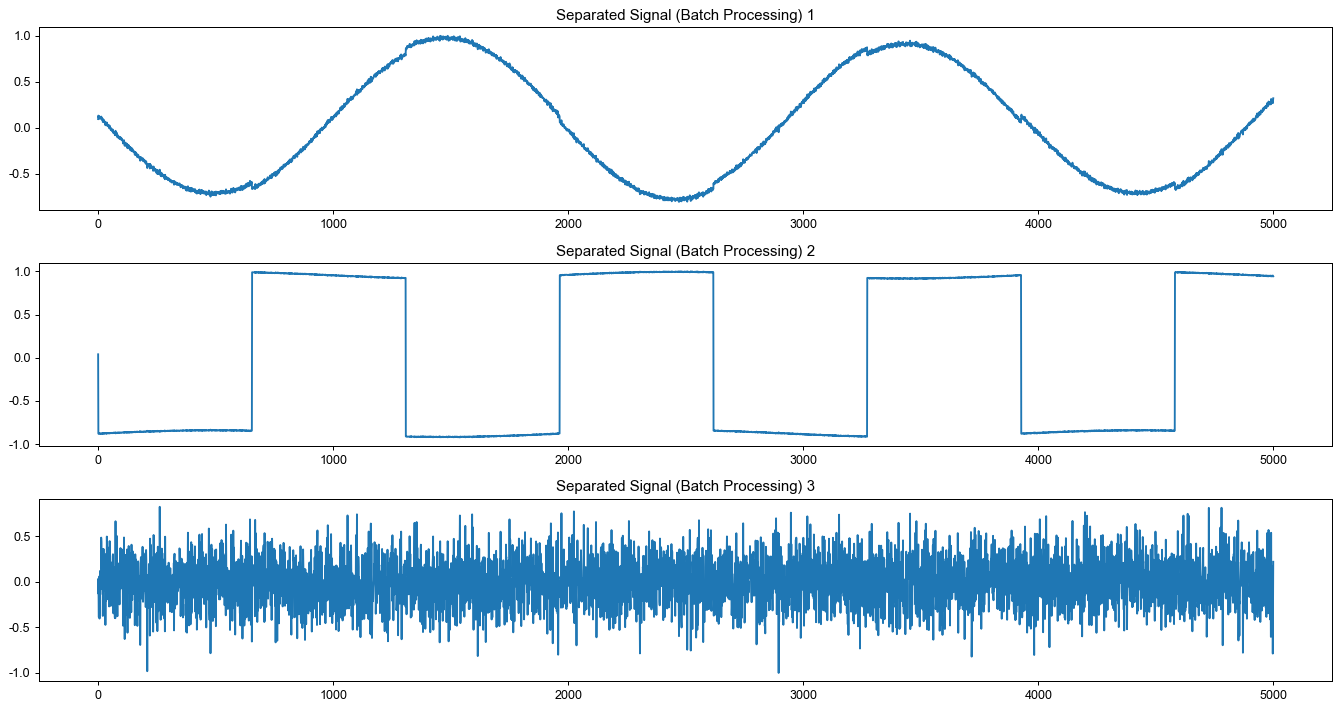

In [6]:
# 假设数据非常大，分块处理
chunk_size = 500  # 每次处理的样本数
n_chunks = n_samples // chunk_size

# 初始化结果矩阵
S_total = np.zeros_like(X)

for i in range(n_chunks):
    start = i * chunk_size
    end = (i + 1) * chunk_size if (i + 1) * chunk_size < n_samples else n_samples
    
    X_chunk = X[start:end]
    S_chunk = ica.transform(X_chunk)
    S_total[start:end] = S_chunk

# 归一化并绘制结果
S_total = S_total / np.max(np.abs(S_total), axis=0)

plot_signals([S_total[:, 0], S_total[:, 1], S_total[:, 2]], title='Separated Signal (Batch Processing)')

![原文参考图，当前结果见代码输出](attachments/img_006.png)

**并行处理示例**

可以使用 `joblib` 来并行处理数据：

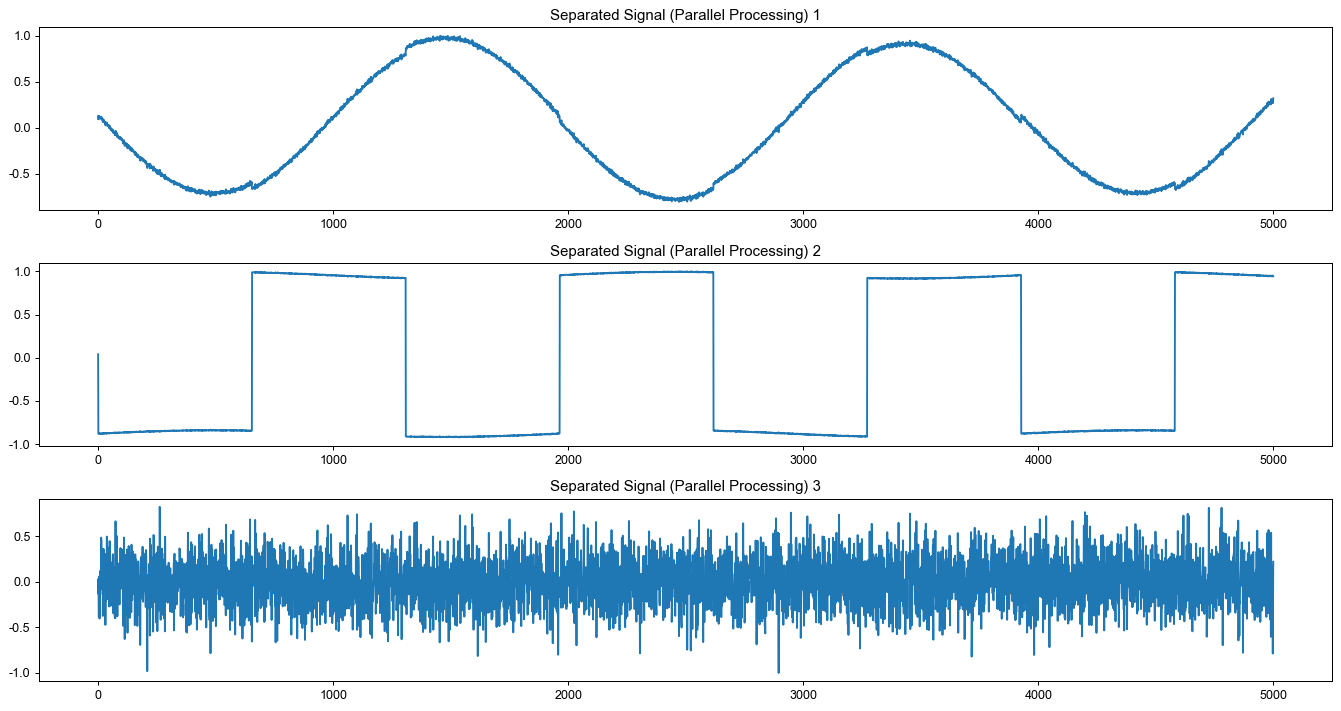

In [7]:
from joblib import Parallel, delayed

def process_chunk(X_chunk):
    return ica.transform(X_chunk)

# 使用并行处理分块数据
S_chunks = Parallel(n_jobs=1)(delayed(process_chunk)(X[i*chunk_size:(i+1)*chunk_size]) for i in range(n_chunks))

# 合并结果
S_total = np.vstack(S_chunks)
S_total = S_total / np.max(np.abs(S_total), axis=0)

# 绘制结果
plot_signals([S_total[:, 0], S_total[:, 1], S_total[:, 2]], title='Separated Signal (Parallel Processing)')

![原文参考图，当前结果见代码输出](attachments/img_007.png)

**复杂可视化**

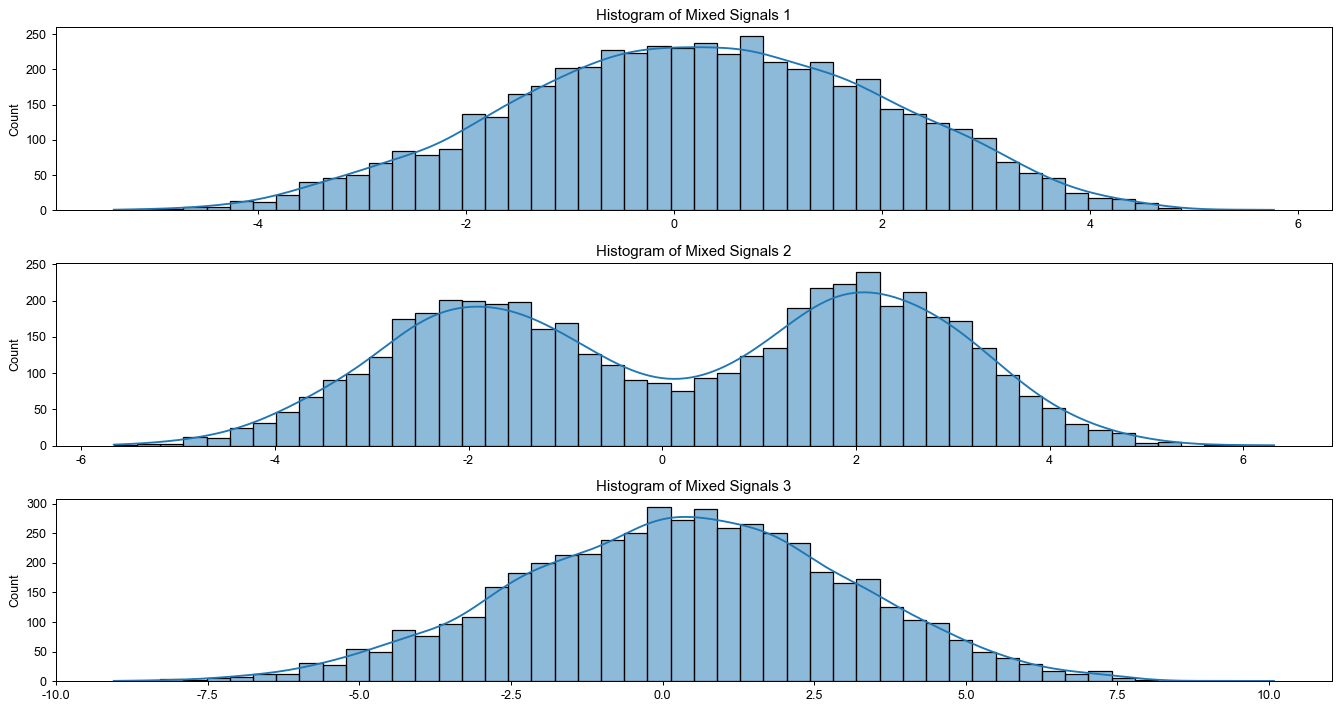

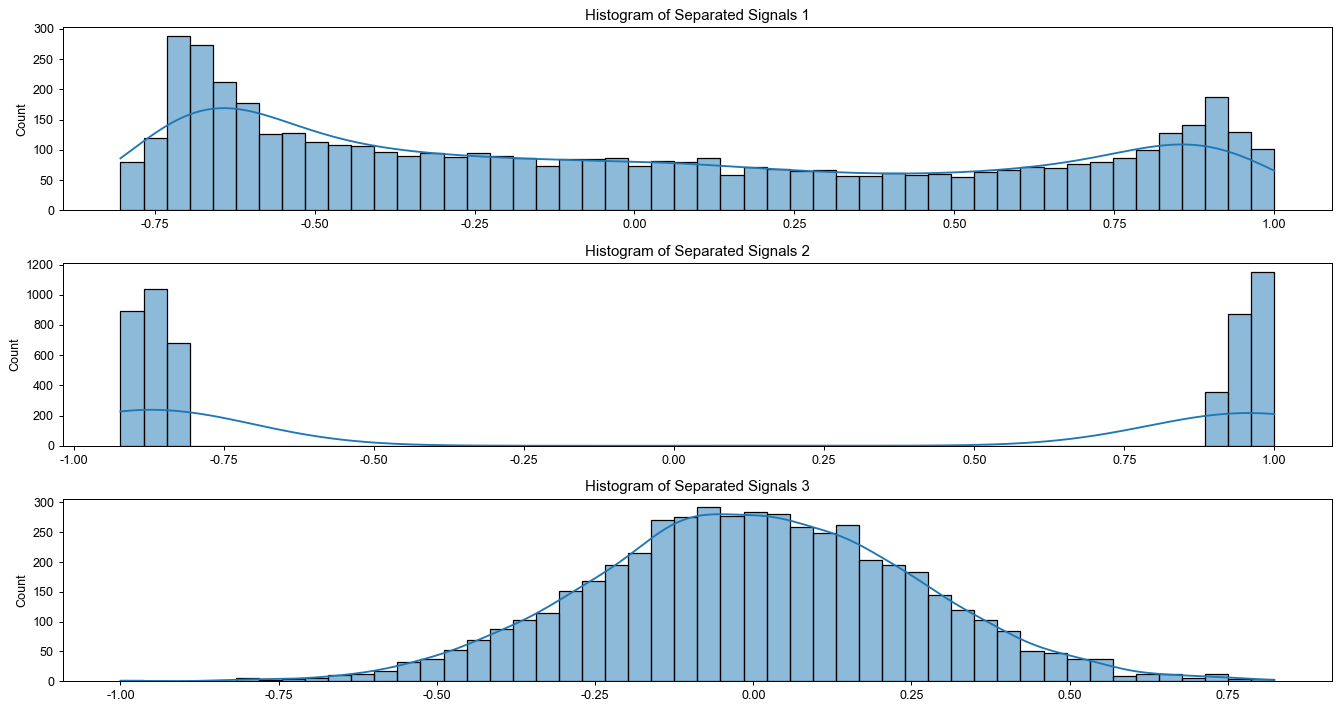

In [8]:
def plot_histograms(signals, title):
    plt.figure(figsize=(15, 8))
    for i, signal in enumerate(signals, 1):
        plt.subplot(len(signals), 1, i)
        sns.histplot(signal, bins=50, kde=True)
        plt.title(f'{title} {i}')
    plt.tight_layout()
    plt.show()

# 绘制混合信号的直方图
plot_histograms([X[:, 0], X[:, 1], X[:, 2]], title='Histogram of Mixed Signals')

# 绘制分离信号的直方图
plot_histograms([S_total[:, 0], S_total[:, 1], S_total[:, 2]], title='Histogram of Separated Signals')

![原文参考图，当前结果见代码输出](attachments/img_008.png)

![原文参考图，当前结果见代码输出](attachments/img_009.png)

通过这些步骤，我们使用了 ICA 算法从混合信号中分离出独立的源信号，并通过多种可视化手段分析了结果。同时，采用了批量处理和并行处理技术优化了算法。

## 应用场景

ICA 主要适用于从观测数据中提取互相独立的源信号的问题，特别是在以下几类场景中：

**1. 信号分离**：从混合信号中分离出独立的源信号，如语音信号分离和盲源分离问题。

**2. 数据降维**：在数据降维过程中提取独立的成分，以便更好地理解数据的结构。

**3. 特征提取**：从复杂数据中提取有意义的特征，如在图像处理和模式识别中的应用。

**4. 时间序列分析**：分离金融数据、气象数据等时间序列中的独立成分。

这里再来聊聊ICA 的优缺点：

**优点**：

**1. 能够处理非高斯信号**：ICA 特别适用于处理非高斯信号，通过最大化非高斯性来分离独立成分。

**2. 无需先验知识**：ICA 不需要混合过程的先验知识，适用于盲源分离问题。

**3. 广泛适用性**：适用于各种类型的数据，包括语音、图像、金融数据等。

**4. 灵活性强**：可以处理多种信号源，尤其是多个独立信号混合的情况。

**缺点**：

**1. 假设限制**：ICA 假设源信号是非高斯且独立的，如果源信号不满足这些假设，分离效果会受到影响。

**2. 敏感性**：对噪声和预处理步骤（如白化）较为敏感，可能会影响结果的稳定性。

**3. 复杂性**：计算复杂度较高，尤其是当数据维度和样本数量较大时，计算资源需求较大。

在使用的时候，大家要注意的一些前提条件：

**1. 独立性假设**：源信号必须是统计独立的，这一假设是 ICA 成功的关键。

**2. 非高斯性**：源信号应是非高斯的，高斯信号的独立性无法通过非高斯性最大化来检测。

**3. 混合过程的线性性**：混合信号应是源信号的线性组合，非线性混合的情况需要更复杂的模型和算法。

**4. 足够的数据量**：需要足够的样本数据以准确估计独立成分，数据量不足会影响结果的可靠性。

ICA 适用于各种需要从混合信号中提取独立成分的问题。其优点在于能够处理非高斯信号和无需先验知识，但同时也存在假设限制和对噪声敏感等缺点。

当然在实际应用中，ICA 已成功应用于神经科学、音频处理、金融数据分析和图像处理等多个领域。